## Jobs Filter Justification

#### Determining an Experience Threshold for Entry-Level Jobs

To ensure a fair comparison between university courses and relevant job opportunities, we first identify an appropriate cutoff for entry-level roles. We examine how the proportion of senior or managerial indicators varies across required experience levels, using signals derived from job titles and descriptions. This exploratory analysis helps determine the point at which roles begin to shift away from entry-level expectations.

(22720, 23)


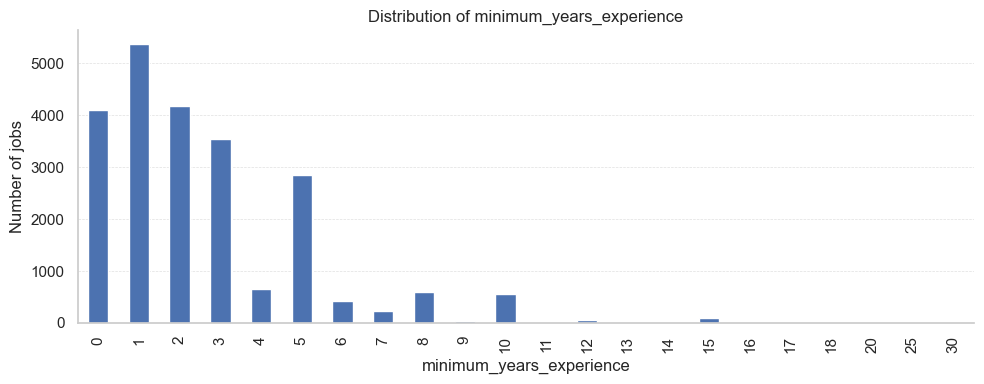

In [ ]:
from pathlib import Path
import os
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")

load_dotenv()

data_root = Path(os.getenv("DATA_ROOT"))
JOBS_PATH = data_root / "processed/jobs/02_jobs_ssoc_mapped.csv"
jobs = pd.read_csv(JOBS_PATH)

print(jobs.shape)

plt.figure(figsize=(10, 4))
jobs['minimum_years_experience'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of minimum_years_experience')
plt.xlabel('minimum_years_experience')
plt.ylabel('Number of jobs')

# formatting
# get current axes
ax = plt.gca()

# clean grid (only horizontal)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
ax.grid(axis='x', visible=False)

# remove border box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/6r/bl_vvdp501993jr71w42mv8c0000gn/T/ipykernel_46779/1955788377.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  jobs["senior"] = jobs['job_text'].str.contains(seniority_pattern, regex=True, na=False)


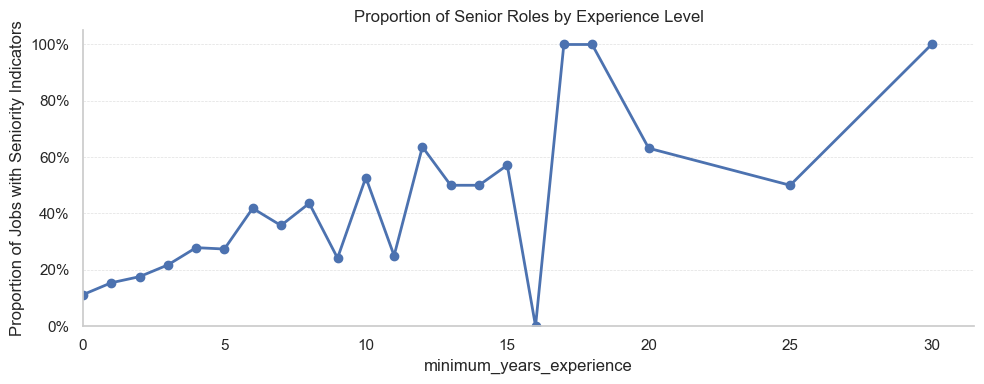

In [26]:
# common patterns for senior roles
seniority_pattern = (
    r'\b('
    r'manager|senior|sr\.?|principal|lead|director|head|supervisor|foreman|'
    r'chief|vp|vice president|executive|team lead|department head'
    r')\b'
)

# label each job as senior or not
jobs["senior"] = jobs['job_text'].str.contains(seniority_pattern, regex=True, na=False)

# for each year of experience, find proportion of jobs that show seniority
senior_rate = (
    jobs
    .groupby('minimum_years_experience')['senior']
    .mean()
    .reset_index()
)

# plot proportion of senior jobs for each experience level
plt.figure(figsize=(10, 4))
plt.plot(
    senior_rate['minimum_years_experience'],
    senior_rate['senior'],
    marker='o',
    linewidth=2
)

plt.xlabel("minimum_years_experience")
plt.ylabel("Proportion of Jobs with Seniority Indicators")
plt.title("Proportion of Senior Roles by Experience Level")

# formatting
# get current axes
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# clean grid (only horizontal)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
ax.grid(axis='x', visible=False)

# remove border box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# align zeros
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

Jobs requiring 0–2 years of experience show a relatively low proportion of senior or managerial indicators (approximately 10–20%), compared to higher experience levels where this proportion increases substantially. This suggests that roles within this range are predominantly non-senior and more representative of entry-level positions.

### Conclusion

The proportion of senior or managerial roles increases with required experience, with jobs requiring 0–2 years of experience having a low proportion of senior responsibilities. Therefore, restricting the analysis to jobs requiring ≤2 years of experience ensures a focus on entry-level roles that are most relevant for evaluating how well undergraduate courses prepare students for the workforce.